# EE-411 Lottery Ticket Hypothesis - Experiment Resnet-18 + Iterative + Random Init + Learning Rate = 0.1 + 3 Trials

**Author:** Tianrui (Jerry)
**Model:** ResNet 18
**Dataset:** [CIFAR-10]  
**Date:** [2026.01.13]

---

## Instructions

1. **Define your model** in the "Model Definition" section
2. **Train baseline model** to get initial performance
3. **Run pruning experiments** using the shared pruning algorithms
4. **Visualize and analyze** your results
5. **Save your results** to the `results/` folder

## Quick Links

- [Paper](https://arxiv.org/abs/1803.03635): "The Lottery Ticket Hypothesis"
- [Shared Code](../../shared/): Training utils and pruning algorithms
- [Results](../../results/): Save checkpoints and figures here

## Setup Run ID

In [1]:
import os
import time
from datetime import datetime

# 1. Generate a unique Run ID (Model + Timestamp)
# e.g., "resnet20_20231027_153045"
model_name = "resnet20_iterative_random_init_LR_0.1_3_trials"  # Or "resnet18"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_id = f"{model_name}_{timestamp}"

# 2. Create specific directories for THIS run
# Instead of dumping everything in 'results/', we make a subfolder
base_dir = "../../results"
run_dir = os.path.join(base_dir, run_id)
ckpt_dir = os.path.join(run_dir, "checkpoints")
fig_dir = os.path.join(run_dir, "figures")

os.makedirs(ckpt_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

print(f"Experiment Initialized: {run_id}")
print(f"Results will be saved to: {run_dir}")

Experiment Initialized: resnet20_iterative_random_init_LR_0.1_3_trials_20260113_123051
Results will be saved to: ../../results/resnet20_iterative_random_init_LR_0.1_3_trials_20260113_123051


## 1. Setup and Imports

In [2]:
import sys
sys.path.append('../..')  # Add project root to path

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm

# Import shared utilities
from shared.training_utils import fit, predict, set_seed, plot_loss
from shared.pruning import (
    iterative_pruning,
    one_shot_pruning,
    one_shot_pruning_efficient,
    random_reinit_pruning,
    get_pruning_config,
    count_parameters,
    evaluate_model,
    apply_mask,
    create_global_mask
)

# Fix random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Data Loading

### For CIFAR-10 (Conv-2, Conv-4, Conv-6, ResNet-18)

In [3]:
# CIFAR-10 Data Loading


# Define transforms
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),  # New ! Crucial for CIFAR-10 
    transforms.RandomHorizontalFlip(),     # New ! Crucial for generalization 
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])


# ============================================================================
# 2. Download and Load Datasets (Twice!)
# ============================================================================

# transform_train
train_set_augmented = torchvision.datasets.CIFAR10(
    root='../../data', 
    train=True, 
    download=True, 
    transform=transform_train  # <--- Augmented data
)

# transform_test
train_set_clean = torchvision.datasets.CIFAR10(
    root='../../data', 
    train=True, 
    download=True, 
    transform=transform_test   # <--- Clean data
)

test_dataset = torchvision.datasets.CIFAR10(
    root='../../data', 
    train=False, 
    download=True, 
    transform=transform_test
)



# ============================================================================
# 3. Split Train/Val using Indices
# ============================================================================
# Make sure it's able to reproduce the same split every time
num_train = len(train_set_augmented) # 50000
indices = list(range(num_train))
split = 45000
seed = 42 

np.random.seed(seed)
np.random.shuffle(indices)

train_idx = indices[:split]
val_idx = indices[split:]

# train_dataset
train_dataset = Subset(train_set_augmented, train_idx)
# val_dataset construction using clean data
val_dataset   = Subset(train_set_clean, val_idx)


# ============================================================================
# 4. Create Data Loaders
# ============================================================================
# Create data loaders
# batch_size = 60  # From paper
batch_size = 128  # Paper uses 128 for ResNet-18

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=2
)

# ============================================================================
# 5. Verify & Config Check
# ============================================================================

print(f"Train: {len(train_dataset)} samples")
print(f"Val:   {len(val_dataset)} samples")
print(f"Test:  {len(test_dataset)} samples")
print(f"Batches per epoch: {len(train_loader)}")

# Automatic Epochs Recommendation
iterations_needed = 30000
steps_per_epoch = len(train_loader)
recommended_epochs = int(np.ceil(iterations_needed / steps_per_epoch))

print(f"\n[Config Check]")
print(f"To reach {iterations_needed} iterations with batch size {batch_size}:")
print(f"You should set EPOCHS >= {recommended_epochs}")

Train: 45000 samples
Val:   5000 samples
Test:  10000 samples
Batches per epoch: 352

[Config Check]
To reach 30000 iterations with batch size 128:
You should set EPOCHS >= 86


## 3. Model Definition

**TODO: Define your model here**

In [4]:
# ResNet18 for CIFAR-10
import copy
import torch
import torch.nn as nn
# from torchvision.models import resnet18
import torch.nn.functional as F
import torch.nn.init as init



# # ResNet-20 for CIFAR-10 (Kaiming He, used in the paper)
# def _weights_init(m):
#     """
#     Kaiming Initialization (He Initialization) as used in the paper.
#     """
#     if isinstance(m, nn.Linear) or isinstance(m, nn.Conv2d):
#         init.kaiming_normal_(m.weight)

def _weights_init(m):
    """
    Paper uses Gaussian Glorot (Xavier Normal) initialization.
    """
    if isinstance(m, nn.Linear) or isinstance(m, nn.Conv2d):
        # Gaussian Glorot (Xavier Normal) is used in the paper
        init.xavier_normal_(m.weight)
        # If there is bias, typically initialized to 0 (though ResNet's Conv usually doesn't have bias)
        if m.bias is not None:
            init.constant_(m.bias, 0)

            

class LambdaLayer(nn.Module):
    def __init__(self, lambd):
        super(LambdaLayer, self).__init__()
        self.lambd = lambd

    def forward(self, x):
        return self.lambd(x)

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.downsample = nn.Sequential() # named as "downsample" as pruning.py
        if stride != 1 or in_planes != planes:
            # Paper Option A: Zero-padding for shortcut
            self.downsample = LambdaLayer(lambda x:
                                        F.pad(x[:, :, ::2, ::2], (0, 0, 0, 0, planes//4, planes//4), "constant", 0))

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.downsample(x)
        out = F.relu(out)
        return out

class ResNet20_CIFAR10(nn.Module):
    def __init__(self):
        super(ResNet20_CIFAR10, self).__init__()
        self.in_planes = 16
        
        # ResNet-20: 3 layers * 3 blocks * 2 convs + 1st conv + 1 linear = 20 layers
        num_blocks = [3, 3, 3] 

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        
        self.layer1 = self._make_layer(BasicBlock, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(BasicBlock, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(BasicBlock, 64, num_blocks[2], stride=2)
        
        self.linear = nn.Linear(64, 10)
        
        # Apply initialization
        self.apply(_weights_init)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.avg_pool2d(out, out.size()[3])
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out



# Create model instance
# model = ResNet18_CIFAR10().to(device)
model = ResNet20_CIFAR10().to(device)
initial_weights_state = copy.deepcopy(model.state_dict())
init_weights_path = os.path.join(ckpt_dir, f"initial_weights_theta0_{run_id}.pth")
torch.save(initial_weights_state, init_weights_path)
print(f"Initial weights saved to: {init_weights_path}")

# Print model info
total_params = count_parameters(model)
print(f"Model: ResNet20_CIFAR10")
print(f"Total parameters: {total_params:,}")
print(f"\nModel architecture:")
print(model)

Initial weights saved to: ../../results/resnet20_iterative_random_init_LR_0.1_3_trials_20260113_123051/checkpoints/initial_weights_theta0_resnet20_iterative_random_init_LR_0.1_3_trials_20260113_123051.pth
Model: ResNet20_CIFAR10
Total parameters: 269,722

Model architecture:
ResNet20_CIFAR10(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsample): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), st

## 4. Baseline Training

Train the unpruned model to establish baseline performance.

In [5]:
# Training configuration (from paper)
# Adjust these based on your model!
     
learning_rate = 0.1 # Paper recommends 0.1 (or 0.03 with warmup)
epochs = 86  

# Optimizer
# optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

optimizer = torch.optim.SGD(
    model.parameters(), 
    lr=learning_rate,             # Paper recommends 0.1 for constant, or 0.03 with warmup
    momentum=0.9, 
    weight_decay=1e-4   # Helps prevent overfitting
)

# Paper: Divide LR by 10 at 20k and 25k iterations
# 20,000 / 352 ≈ 57 epochs
# 25,000 / 352 ≈ 71 epochs
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, 
    milestones=[57, 71], 
    gamma=0.01
)

# --- Dynamic Print ---
optimizer_name = optimizer.__class__.__name__
current_lr = optimizer.param_groups[0]['lr']

print(f"Training configuration:")
print(f"  Optimizer: {optimizer_name}") # Dynamic!
print(f"  Learning rate: {learning_rate}")
print(f"  Epochs: {epochs}")
print(f"  Batch size: {batch_size}")
print(f"\nStarting training...\n")

test_loss, test_accuracy = predict(model, test_loader, device)

Training configuration:
  Optimizer: SGD
  Learning rate: 0.1
  Epochs: 86
  Batch size: 128

Starting training...

Test set: Avg. loss: 2.8741, Accuracy: 1049/10000 (10%)


In [ ]:
# # Train using shared training_utils
# losses = fit(
#     model=model,
#     train_dataloader=train_loader,
#     optimizer=optimizer,
#     epochs=epochs,
#     device=device,
#     scheduler=scheduler  # New! Don't forget to pass the scheduler!
# )

# # Evaluate on test set
# test_loss, test_accuracy = predict(model, test_loader, device)

# print(f"\n{'='*60}")
# print(f"Baseline Results")
# print(f"{'='*60}")
# print(f"Test Accuracy: {test_accuracy:.2f}%")
# print(f"Test Loss: {test_loss:.4f}")

### Visualize Training

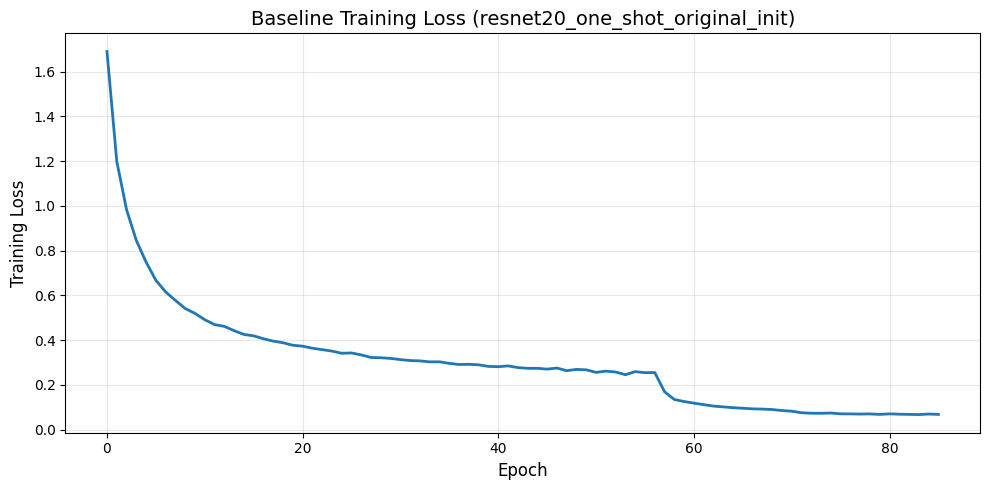

Loss figure saved to: ../../results/resnet20_one_shot_original_init_20260110_215316/figures/baseline_loss_resnet20_one_shot_original_init_20260110_215316.png


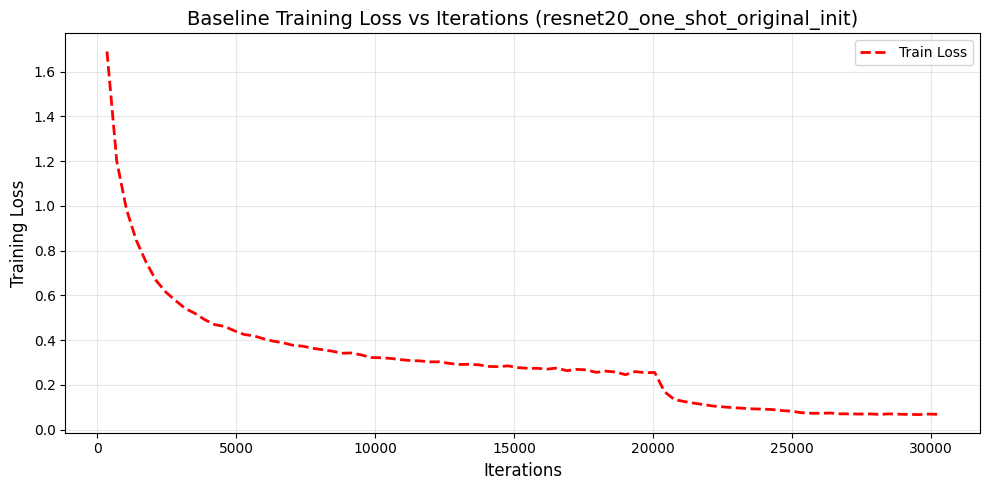

Iteration-based loss figure saved to: ../../results/resnet20_one_shot_original_init_20260110_215316/figures/baseline_loss_iter_resnet20_one_shot_original_init_20260110_215316.png


In [ ]:
# iterations_per_epoch = len(train_loader)
# # ================= Drawing Figure 1: X-axis = Epochs =================

# plt.figure(figsize=(10, 5))
# plt.plot(losses, linewidth=2)
# plt.xlabel('Epoch', fontsize=12)
# plt.ylabel('Training Loss', fontsize=12)
# plt.title(f'Baseline Training Loss ({model_name})', fontsize=14)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()

# # Save with run_id
# loss_fig_path = os.path.join(fig_dir, f"baseline_loss_{run_id}.png")
# plt.savefig(loss_fig_path, dpi=150)
# plt.show()

# print(f"Loss figure saved to: {loss_fig_path}")

# # ================= Drawing Figure 2: X-axis = Iterations =================
# iterations_x = [i * iterations_per_epoch for i in range(1, len(losses) + 1)]

# plt.figure(figsize=(10, 5))
# plt.plot(iterations_x, losses, linewidth=2, color='red', linestyle='--', label='Train Loss')
# plt.xlabel('Iterations', fontsize=12)
# plt.ylabel('Training Loss', fontsize=12)
# plt.title(f'Baseline Training Loss vs Iterations ({model_name})', fontsize=14)
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()

# # Save Iteration Figure
# loss_fig_path_iter = os.path.join(fig_dir, f"baseline_loss_iter_{run_id}.png")
# plt.savefig(loss_fig_path_iter, dpi=150)
# plt.show()
# print(f"Iteration-based loss figure saved to: {loss_fig_path_iter}")

### Save Baseline Model

In [ ]:
# # --- Save Baseline Model ---
# # Save with the unique run_id in the filename
# baseline_path = os.path.join(ckpt_dir, f"baseline_{run_id}.pth")

# torch.save({
#     'model_state_dict': model.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
#     'test_accuracy': test_accuracy,
#     'test_loss': test_loss,
#     'epochs': epochs,
#     'config': {
#         'optimizer': optimizer_name,
#         'lr': current_lr
#     }
# }, baseline_path)

# print(f"Baseline model saved to: {baseline_path}")

Baseline model saved to: ../../results/resnet20_one_shot_original_init_20260110_215316/checkpoints/baseline_resnet20_one_shot_original_init_20260110_215316.pth


## 5. Pruning Experiments

### 5.1 Iterative Pruning

Run the main pruning experiment from the paper.

In [6]:
# Get pruning configuration for your model
# Options: 'lenet', 'conv2', 'conv4', 'conv6', 'resnet18', 'resnet20'

pruning_config = get_pruning_config('resnet18')

print("Pruning Configuration:")
for key, value in pruning_config.items():
    print(f"  {key}: {value}")


Pruning Configuration:
  prune_rate_conv: 0.2
  prune_rate_fc: 0.0
  pruning_strategy: global
  description: ResNet-18 for CIFAR-10


In [7]:
# --- Seed Configuration for Trials ---
SEEDS = [42, 43, 44]
lr = 0.1
epochs_per_round = 86  # ~30k iterations

# --- Data Preparation Function (Re-usable for every seed) ---
def get_dataloaders(seed):
    """Re-creates dataloaders with specific seed-based shuffling"""
    
    # Define transforms
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    # Load Datasets
    train_set_augmented = torchvision.datasets.CIFAR10(root='../../data', train=True, download=True, transform=transform_train)
    train_set_clean = torchvision.datasets.CIFAR10(root='../../data', train=True, download=True, transform=transform_test)
    test_dataset = torchvision.datasets.CIFAR10(root='../../data', train=False, download=True, transform=transform_test)

    # Split Train/Val (Dependent on Seed)
    num_train = len(train_set_augmented)
    indices = list(range(num_train))
    split = 45000
    
    # Temporarily set numpy seed for split consistency within this function call
    rng = np.random.RandomState(seed) 
    rng.shuffle(indices)

    train_idx = indices[:split]
    val_idx = indices[split:]

    train_dataset = Subset(train_set_augmented, train_idx)
    val_dataset = Subset(train_set_clean, val_idx)

    # Create Loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    
    return train_loader, val_loader, test_loader


In [8]:
# ============================================================================
# PHASE 1: Iterative Pruning (Winning Tickets)
# ============================================================================
print(f"\n{'='*40}")
print("PHASE 1: Iterative Pruning Experiments")
print(f"{'='*40}")

all_trials_iterative = []

for trial_idx, seed in enumerate(SEEDS):
    print(f"\n>>> Starting Iterative Trial {trial_idx + 1}/{len(SEEDS)} | Seed {seed}")
    
    # 1. Set seed for reproducibility
    set_seed(seed)
    
    # 2. Prepare Data & Model
    train_loader, val_loader, test_loader = get_dataloaders(seed)
    model = ResNet20_CIFAR10().to(device)
    
    # 3. Run Iterative Pruning
    iter_results = iterative_pruning(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        val_loader=val_loader,
        optimizer_class=torch.optim.SGD,
        optimizer_kwargs={'lr': lr, 'momentum': 0.9, 'weight_decay': 1e-4},
        device=device,
        config=pruning_config,
        epochs_per_round=epochs_per_round,
        n_rounds=15,
        verbose=True
    )
    
    all_trials_iterative.append(iter_results)

# 4. Save Iterative Results immediately
iterative_save_path = os.path.join(ckpt_dir, f"iterative_results_{run_id}.pth")
torch.save({
    'trials': all_trials_iterative,
    'seeds': SEEDS,
    'config': pruning_config,
    'lr': lr
}, iterative_save_path)
print(f"Saved Iterative results to: {iterative_save_path}")


PHASE 1: Iterative Pruning Experiments

>>> Starting Iterative Trial 1/3 | Seed 42

Seed set to: 42
Starting Iterative Pruning
Initial parameters: 269,722
Pruning strategy: global
Conv prune rate: 20.0%
FC prune rate: 0.0%

Round 1/15
Scheduler enabled: MultiStepLR at epochs 57 and 71
Epoch 01 | Train Loss: 1.7335 | Val Loss: 1.5379 | Val Acc: 44.48% | Test Acc: 45.66%
Epoch 02 | Train Loss: 1.2425 | Val Loss: 1.1329 | Val Acc: 59.66% | Test Acc: 59.87%
Epoch 03 | Train Loss: 0.9948 | Val Loss: 1.0346 | Val Acc: 64.60% | Test Acc: 64.23%
Epoch 04 | Train Loss: 0.8341 | Val Loss: 0.8707 | Val Acc: 70.86% | Test Acc: 70.96%
Epoch 05 | Train Loss: 0.7279 | Val Loss: 0.7911 | Val Acc: 72.88% | Test Acc: 72.84%
Epoch 06 | Train Loss: 0.6611 | Val Loss: 0.7087 | Val Acc: 76.04% | Test Acc: 76.08%
Epoch 07 | Train Loss: 0.6064 | Val Loss: 0.6352 | Val Acc: 78.24% | Test Acc: 77.82%
Epoch 08 | Train Loss: 0.5646 | Val Loss: 0.7465 | Val Acc: 75.30% | Test Acc: 75.62%
Epoch 09 | Train Loss: 0.

Epoch 10/86: 100%|██████████| 352/352 [00:05<00:00, 65.70it/s]


Epoch 10 | Train Loss: 0.5068 | Val Loss: 0.6170 | Val Acc: 79.52% | Test Acc: 79.09%
Epoch 11 | Train Loss: 0.4928 | Val Loss: 0.6146 | Val Acc: 79.88% | Test Acc: 79.26%
Epoch 12 | Train Loss: 0.4741 | Val Loss: 0.6095 | Val Acc: 80.04% | Test Acc: 79.49%
Epoch 13 | Train Loss: 0.4581 | Val Loss: 0.5761 | Val Acc: 81.34% | Test Acc: 80.70%
Epoch 14 | Train Loss: 0.4447 | Val Loss: 0.5335 | Val Acc: 82.24% | Test Acc: 82.28%
Epoch 15 | Train Loss: 0.4230 | Val Loss: 0.5814 | Val Acc: 80.98% | Test Acc: 80.97%
Epoch 16 | Train Loss: 0.4171 | Val Loss: 0.5849 | Val Acc: 80.82% | Test Acc: 81.08%
Epoch 17 | Train Loss: 0.4050 | Val Loss: 0.5703 | Val Acc: 80.90% | Test Acc: 81.43%
Epoch 18 | Train Loss: 0.3956 | Val Loss: 0.4904 | Val Acc: 83.48% | Test Acc: 83.16%
Epoch 19 | Train Loss: 0.3804 | Val Loss: 0.5768 | Val Acc: 81.94% | Test Acc: 81.57%


Epoch 20/86: 100%|██████████| 352/352 [00:06<00:00, 58.39it/s]


Epoch 20 | Train Loss: 0.3735 | Val Loss: 0.5048 | Val Acc: 83.80% | Test Acc: 83.47%
Epoch 21 | Train Loss: 0.3668 | Val Loss: 0.7557 | Val Acc: 76.42% | Test Acc: 77.19%
Epoch 22 | Train Loss: 0.3606 | Val Loss: 0.4969 | Val Acc: 83.78% | Test Acc: 83.94%
Epoch 23 | Train Loss: 0.3504 | Val Loss: 0.6218 | Val Acc: 81.46% | Test Acc: 80.50%
Epoch 24 | Train Loss: 0.3452 | Val Loss: 0.4571 | Val Acc: 85.00% | Test Acc: 85.01%
Epoch 25 | Train Loss: 0.3357 | Val Loss: 0.5978 | Val Acc: 81.52% | Test Acc: 81.26%
Epoch 26 | Train Loss: 0.3337 | Val Loss: 0.5377 | Val Acc: 83.10% | Test Acc: 82.64%
Epoch 27 | Train Loss: 0.3275 | Val Loss: 0.4902 | Val Acc: 84.48% | Test Acc: 84.08%
Epoch 28 | Train Loss: 0.3254 | Val Loss: 0.4964 | Val Acc: 84.48% | Test Acc: 83.72%
Epoch 29 | Train Loss: 0.3182 | Val Loss: 0.4881 | Val Acc: 84.18% | Test Acc: 83.84%


...

Epoch 60 | Train Loss: 0.5249 | Val Loss: 0.5250 | Val Acc: 81.90% | Test Acc: 81.04%
Epoch 61 | Train Loss: 0.5170 | Val Loss: 0.5269 | Val Acc: 82.08% | Test Acc: 80.82%
Epoch 62 | Train Loss: 0.5116 | Val Loss: 0.5262 | Val Acc: 81.68% | Test Acc: 80.96%
Epoch 63 | Train Loss: 0.5094 | Val Loss: 0.5216 | Val Acc: 82.18% | Test Acc: 80.62%
Epoch 64 | Train Loss: 0.5088 | Val Loss: 0.5174 | Val Acc: 82.00% | Test Acc: 80.98%
Epoch 65 | Train Loss: 0.5075 | Val Loss: 0.5253 | Val Acc: 81.70% | Test Acc: 80.68%
Epoch 66 | Train Loss: 0.5049 | Val Loss: 0.5153 | Val Acc: 82.08% | Test Acc: 81.41%
Epoch 67 | Train Loss: 0.4962 | Val Loss: 0.5227 | Val Acc: 82.26% | Test Acc: 81.12%
Epoch 68 | Train Loss: 0.5009 | Val Loss: 0.5081 | Val Acc: 82.08% | Test Acc: 81.27%
Epoch 69 | Train Loss: 0.4960 | Val Loss: 0.5241 | Val Acc: 81.80% | Test Acc: 80.68%


Epoch 70/86: 100%|██████████| 352/352 [00:05<00:00, 59.79it/s]


Epoch 70 | Train Loss: 0.4948 | Val Loss: 0.5274 | Val Acc: 81.82% | Test Acc: 81.01%
Epoch 71 | Train Loss: 0.4941 | Val Loss: 0.5246 | Val Acc: 81.78% | Test Acc: 80.84%
 -> Scheduler Step! Current LR: 0.0010000000000000002
Epoch 72 | Train Loss: 0.4903 | Val Loss: 0.5080 | Val Acc: 82.14% | Test Acc: 81.58%
 -> Scheduler Step! Current LR: 0.0010000000000000002
Epoch 73 | Train Loss: 0.4854 | Val Loss: 0.5054 | Val Acc: 82.38% | Test Acc: 81.42%
Epoch 74 | Train Loss: 0.4823 | Val Loss: 0.5060 | Val Acc: 82.36% | Test Acc: 81.49%
Epoch 75 | Train Loss: 0.4840 | Val Loss: 0.5022 | Val Acc: 82.28% | Test Acc: 81.72%
Epoch 76 | Train Loss: 0.4830 | Val Loss: 0.5031 | Val Acc: 82.06% | Test Acc: 81.47%
Epoch 77 | Train Loss: 0.4816 | Val Loss: 0.5031 | Val Acc: 82.06% | Test Acc: 81.57%
Epoch 78 | Train Loss: 0.4810 | Val Loss: 0.5029 | Val Acc: 82.20% | Test Acc: 81.50%
Epoch 79 | Train Loss: 0.4810 | Val Loss: 0.5047 | Val Acc: 82.24% | Test Acc: 81.56%


Epoch 80/86: 100%|██████████| 352/352 [00:06<00:00, 55.83it/s]


Epoch 80 | Train Loss: 0.4782 | Val Loss: 0.5017 | Val Acc: 82.40% | Test Acc: 81.54%
Epoch 81 | Train Loss: 0.4795 | Val Loss: 0.5035 | Val Acc: 82.56% | Test Acc: 81.60%
Epoch 82 | Train Loss: 0.4772 | Val Loss: 0.5011 | Val Acc: 82.36% | Test Acc: 81.56%
Epoch 83 | Train Loss: 0.4797 | Val Loss: 0.5032 | Val Acc: 82.36% | Test Acc: 81.56%
Epoch 84 | Train Loss: 0.4778 | Val Loss: 0.5031 | Val Acc: 82.54% | Test Acc: 81.55%
Epoch 85 | Train Loss: 0.4772 | Val Loss: 0.5031 | Val Acc: 82.52% | Test Acc: 81.64%
Epoch 86 | Train Loss: 0.4801 | Val Loss: 0.5037 | Val Acc: 82.64% | Test Acc: 81.56%

Round 15 Results:
  Test Accuracy: 81.56%
  Remaining Parameters: 11,444.0 (4.24%)

Iterative Pruning Complete!
Saved Iterative results to: ../../results/resnet20_iterative_random_init_LR_0.1_3_trials_20260113_123051/checkpoints/iterative_results_resnet20_iterative_random_init_LR_0.1_3_trials_20260113_123051.pth


In [9]:
# --- Data Aggregation ---
# Assuming all trials have the same number of rounds and pruning rates
n_rounds = len(all_trials_iterative[0])
n_trials = len(all_trials_iterative)

# Initialize lists to store aggregated data
rounds = []
remaining_params_pct = []
remaining_params = []
acc_means = []
acc_stds = []

for r_idx in range(n_rounds):
    # Extract data for this specific round across all trials
    # Structure: [Trial1_RoundX, Trial2_RoundX, Trial3_RoundX]
    round_data = [trial[r_idx] for trial in all_trials_iterative]
    
    # Static data (same for all trials)
    rounds.append(round_data[0]['round'])
    remaining_params_pct.append(round_data[0]['remaining_params_pct'])
    remaining_params.append(round_data[0]['remaining_params'])
    
    # Variable data (Accuracy) - Calculate Mean and Std
    accuracies = [r['test_accuracy'] for r in round_data]
    acc_means.append(np.mean(accuracies))
    acc_stds.append(np.std(accuracies))

# --- Print Summary Table ---
print("\n" + "="*80)
print(f"Pruning Results Summary ({n_trials} Trials Aggregated)")
print("="*80)
print(f"{'Round':<8} {'Params %':<12} {'Params':<15} {'Mean Acc %':<12} {'Std Dev':<10}")
print("-"*80)

for i in range(n_rounds):
    print(f"{rounds[i]:<8} {remaining_params_pct[i]:<12.2f} "
          f"{remaining_params[i]:<15,} {acc_means[i]:<12.2f} ± {acc_stds[i]:<10.2f}")
print("="*80)


Pruning Results Summary (3 Trials Aggregated)
Round    Params %     Params          Mean Acc %   Std Dev   
--------------------------------------------------------------------------------
1        80.15        216,183.0       90.79        ± 0.30      
2        64.27        173,351.0       90.56        ± 0.16      
3        51.57        139,086.0       90.27        ± 0.30      
4        41.40        111,674.0       89.92        ± 0.16      
5        33.27        89,744.0        89.73        ± 0.09      
6        26.77        72,200.0        89.13        ± 0.03      
7        21.56        58,165.0        88.67        ± 0.23      
8        17.40        46,937.0        88.38        ± 0.50      
9        14.07        37,955.0        87.53        ± 0.08      
10       11.41        30,769.0        86.98        ± 0.15      
11       9.28         25,020.0        86.07        ± 0.15      
12       7.57         20,421.0        85.26        ± 0.27      
13       6.21         16,742.0        84.0

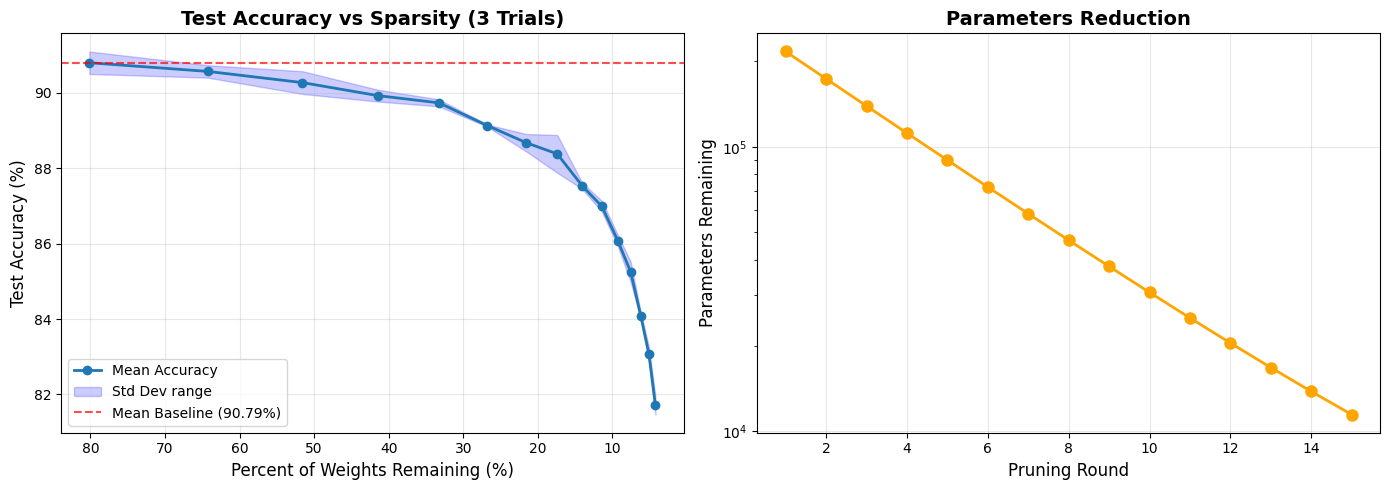

Pruning figure saved to: ../../results/resnet20_iterative_random_init_LR_0.1_3_trials_20260113_123051/figures/Iterative_pruning_results_multi_trial_resnet20_iterative_random_init_LR_0.1_3_trials_20260113_123051.png


In [11]:
# --- Visualize with Error Bars ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Convert to numpy arrays for plotting
x_pct = np.array(remaining_params_pct)
y_mean = np.array(acc_means)
y_std = np.array(acc_stds)

# Plot 1: Accuracy vs Sparsity (Mean + Std Shadow)
# Plot the mean line
ax1.plot(x_pct, y_mean, 'o-', linewidth=2, markersize=6, label='Mean Accuracy')

# Plot the shadow (Mean +/- Std) 

ax1.fill_between(x_pct, y_mean - y_std, y_mean + y_std, alpha=0.2, color='blue', label='Std Dev range')

# Baseline Handling: Calculate mean baseline from Round 1 (0% pruned)
baseline_mean = y_mean[0] 
ax1.axhline(y=baseline_mean, color='r', linestyle='--', label=f'Mean Baseline ({baseline_mean:.2f}%)', alpha=0.7)

ax1.set_xlabel('Percent of Weights Remaining (%)', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title(f'Test Accuracy vs Sparsity ({n_trials} Trials)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.invert_xaxis()  # 100% -> 0%

# Plot 2: Params Reduction (Deterministic, no error bars needed)
ax2.plot(rounds, remaining_params, 'o-', linewidth=2, markersize=8, color='orange')
ax2.set_xlabel('Pruning Round', fontsize=12)
ax2.set_ylabel('Parameters Remaining', fontsize=12)
ax2.set_title('Parameters Reduction', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log') 

plt.tight_layout()

# Save Pruning Figure
# Ensure fig_dir exists in your context
pruning_fig_path = os.path.join(fig_dir, f"Iterative_pruning_results_multi_trial_{run_id}.png")
plt.savefig(pruning_fig_path, dpi=150)
plt.show()

print(f"Pruning figure saved to: {pruning_fig_path}")

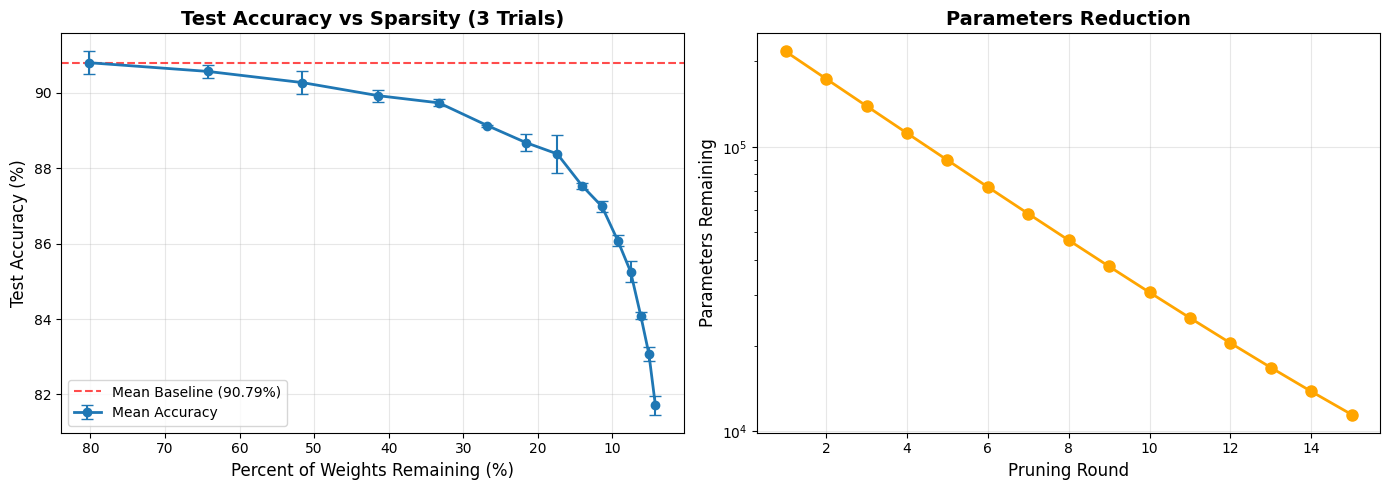

Pruning figure saved to: ../../results/resnet20_iterative_random_init_LR_0.1_3_trials_20260113_123051/figures/Iterative_pruning_results_multi_trial_errorbars_resnet20_iterative_random_init_LR_0.1_3_trials_20260113_123051.png


In [13]:
import matplotlib.pyplot as plt
import os
import numpy as np

# --- Visualize with Error Bars (Vertical Lines) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Convert to numpy arrays for plotting
x_pct = np.array(remaining_params_pct)
y_mean = np.array(acc_means)
y_std = np.array(acc_stds)

# ==============================================================================
# Plot 1: Accuracy vs Sparsity (Using Error Bars)
# ==============================================================================

# ax1.errorbar 是关键函数
# x, y: 坐标
# yerr: 误差范围 (这里用标准差)
# fmt='o-': 样式 (圆点 + 实线)
# capsize=4: 误差棒顶部和底部的小横杠宽度 (让它看起来更像论文)
# elinewidth=1.5: 误差棒的线条粗细
ax1.errorbar(x_pct, y_mean, yerr=y_std, fmt='o-', 
             linewidth=2, markersize=6, capsize=4, elinewidth=1.5,
             color='tab:blue', ecolor='tab:blue', label='Mean Accuracy')

# Baseline Handling
baseline_mean = y_mean[0] 
ax1.axhline(y=baseline_mean, color='r', linestyle='--', label=f'Mean Baseline ({baseline_mean:.2f}%)', alpha=0.7)

ax1.set_xlabel('Percent of Weights Remaining (%)', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title(f'Test Accuracy vs Sparsity ({n_trials} Trials)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.invert_xaxis()  # 100% -> 0% (Standard for pruning plots)

# ==============================================================================
# Plot 2: Params Reduction (No changes needed)
# ==============================================================================
ax2.plot(rounds, remaining_params, 'o-', linewidth=2, markersize=8, color='orange')
ax2.set_xlabel('Pruning Round', fontsize=12)
ax2.set_ylabel('Parameters Remaining', fontsize=12)
ax2.set_title('Parameters Reduction', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log') 

plt.tight_layout()

# Save Pruning Figure
if 'fig_dir' not in globals(): fig_dir = "." # Fallback if fig_dir is not defined
pruning_fig_path = os.path.join(fig_dir, f"Iterative_pruning_results_multi_trial_errorbars_{run_id}.png")
plt.savefig(pruning_fig_path, dpi=300) # Increased DPI for better quality
plt.show()

print(f"Pruning figure saved to: {pruning_fig_path}")

In [12]:
# --- Identify Winning Tickets (Based on Mean Accuracy) ---

# Define Baseline: Mean accuracy of the unpruned model (Round 1)
baseline_mean_acc = acc_means[0] 

winning_tickets_indices = []

# Loop through aggregated stats
for i in range(n_rounds):
    # Criteria: Mean Accuracy >= 98% of Mean Baseline
    if acc_means[i] >= baseline_mean_acc * 0.98:
        winning_tickets_indices.append(i)

print(f"\n{'='*70}")
print(f"Winning Ticket Analysis (Based on {n_trials} Trials Mean)")
print(f"{'='*70}")
print(f"Mean Baseline Accuracy: {baseline_mean_acc:.2f}%")
print(f"\nWinning Tickets (Mean Acc >= {baseline_mean_acc * 0.98:.2f}%):")
print(f"{'Round':<8} {'Sparsity %':<12} {'Params':<15} {'Mean Acc %':<12}")
print("-"*70)

best_ticket_idx = -1
min_params = float('inf')

for idx in winning_tickets_indices:
    sparsity = 100 - remaining_params_pct[idx]
    print(f"{rounds[idx]:<8} {sparsity:<12.1f} "
          f"{remaining_params[idx]:<15,} {acc_means[idx]:<12.2f}")
    
    # Track the best ticket (most sparse)
    if remaining_params[idx] < min_params:
        min_params = remaining_params[idx]
        best_ticket_idx = idx

if best_ticket_idx != -1:
    print(f"\nBest Winning Ticket (Most Sparse):")
    print(f"  Round: {rounds[best_ticket_idx]}")
    print(f"  Sparsity: {100 - remaining_params_pct[best_ticket_idx]:.1f}%")
    print(f"  Parameters: {remaining_params[best_ticket_idx]:,}")
    print(f"  Mean Accuracy: {acc_means[best_ticket_idx]:.2f}%")


Winning Ticket Analysis (Based on 3 Trials Mean)
Mean Baseline Accuracy: 90.79%

Winning Tickets (Mean Acc >= 88.98%):
Round    Sparsity %   Params          Mean Acc %  
----------------------------------------------------------------------
1        19.8         216,183.0       90.79       
2        35.7         173,351.0       90.56       
3        48.4         139,086.0       90.27       
4        58.6         111,674.0       89.92       
5        66.7         89,744.0        89.73       
6        73.2         72,200.0        89.13       

Best Winning Ticket (Most Sparse):
  Round: 6
  Sparsity: 73.2%
  Parameters: 72,200.0
  Mean Accuracy: 89.13%


### 5.2 Random Init

In [ ]:
# ============================================================================
# PHASE 2: Random Reinitialization (Control)
# ============================================================================
print(f"\n{'='*40}")
print("PHASE 2: Random Reinitialization Experiments")
print(f"{'='*40}")

all_trials_random = []

for trial_idx, seed in enumerate(SEEDS):
    print(f"\n>>> Starting Random Init Trial {trial_idx + 1}/{len(SEEDS)} | Seed {seed}")
    
    # 1. Set seed (Ensure data shuffle matches Phase 1)
    set_seed(seed)
    
    # 2. Prepare Data
    train_loader, val_loader, test_loader = get_dataloaders(seed)
    
    # 3. Retrieve Masks from Phase 1
    current_iter_results = all_trials_iterative[trial_idx]
    
    trial_random_results = []
    
    # 4. Create a fresh base model for re-init
    base_model_rnd = ResNet20_CIFAR10().to(device)
    
    # 5. Iterate through rounds using Phase 1 masks
    for res in current_iter_results:
        mask = res['mask']
        if mask is None: continue # Skip Round 0 (no pruning)
        
        print(f"   -> Random Reinit for Sparsity: {res['remaining_params_pct']:.2f}%")
        
        # Run Random Reinit Pruning
        # [CRITICAL UPDATE]: Passing 'config' so the correct scheduler is used
        rand_res = random_reinit_pruning(
            model=copy.deepcopy(base_model_rnd),
            train_loader=train_loader,
            test_loader=test_loader,
            val_loader=val_loader,
            optimizer_class=torch.optim.SGD,
            optimizer_kwargs={'lr': lr, 'momentum': 0.9, 'weight_decay': 1e-4},
            device=device,
            mask=mask,
            # Pass the same config structure you used in Phase 1
            config=pruning_config,
            epochs=epochs_per_round,
            verbose=False 
        )
        
        # Add metadata for plotting
        rand_res['remaining_params_pct'] = res['remaining_params_pct']
        rand_res['round'] = res['round']
        trial_random_results.append(rand_res)
        
    all_trials_random.append(trial_random_results)

# 6. Save Random Init Results separately
random_save_path = os.path.join(ckpt_dir, f"random_init_results_{run_id}.pth")
torch.save({
    'trials': all_trials_random,
    'seeds': SEEDS,
    'config': pruning_config,
    'lr': lr
}, random_save_path)
print(f"Saved Random Init results to: {random_save_path}")

In [11]:
import torch
import os
import copy
# 假设 random_reinit_pruning 在当前文件的作用域内，或者从模块导入
# from shared.pruning import random_reinit_pruning 

# ==========================================
# 0. Setup & Configuration
# ==========================================
# 确保你的 ResNet20_CIFAR10 类已经定义或导入
# 确保 device, train_loader, test_loader 已经定义

# load_path = "../../results/resnet20_iterative_random_init_20260111_011546/checkpoints/iterative_pruning_results_resnet20_iterative_random_init_20260111_011546.pth"
# load_path = "../../results/resnet20_iterative_random_init_LR_0.01_20260111_205802/checkpoints/iterative_pruning_results_resnet20_iterative_random_init_LR_0.01_20260111_205802.pth"
load_path = "../../results/resnet20_iterative_random_init_LR_0.1_20260112_025542/checkpoints/iterative_pruning_results_resnet20_iterative_random_init_LR_0.1_20260112_025542.pth"

if not os.path.exists(load_path):
    raise FileNotFoundError(f"File not found: {load_path}")

# ==========================================
# 1. Load Iterative Pruning Results
# ==========================================
checkpoint_data = torch.load(load_path)
iterative_results = checkpoint_data['results']
loaded_config = checkpoint_data.get('config', {}) # 获取保存的配置

print(f"Successfully loaded results for {len(iterative_results)} stages.")

# ==========================================
# 2. Extract Hyperparameters (Critical for Matching!)
# ==========================================
# 尝试从 config 中恢复参数，如果找不到则使用默认值
# 这样能保证你的 Random Init 用的 LR 和 Epochs 与 Winning Ticket 完全一致
# saved_lr = loaded_config.get('optimizer_kwargs', {}).get('lr', 0.1) # 默认0.1，但建议检查
# saved_epochs = loaded_config.get('epochs_per_round', 86)           # 默认86

saved_lr = 0.1  # Manually set to match the experiment
saved_epochs = 86

print("\n" + "="*50)
print(f"Detected Hyperparameters from Checkpoint:")
print(f"  Learning Rate: {saved_lr}")
print(f"  Epochs per round: {saved_epochs}")
print("="*50 + "\n")

Successfully loaded results for 15 stages.

Detected Hyperparameters from Checkpoint:
  Learning Rate: 0.1
  Epochs per round: 86



In [12]:
random_init_results = []

# ==========================================
# 3. Iterate through each Mask and Train
# ==========================================
print("Starting Random Init control experiment...")

for i, res in enumerate(iterative_results):
    # Retrieve mask and sparsity information
    mask = res['mask']
    sparsity = res['remaining_params_pct']
    
    # Skip if Mask is None (Level 0 / Baseline)
    # 也可以跑，但通常 Random Init 的 Baseline 就是普通的训练，没必要重复跑，除非为了验证随机性
    if mask is None:
        continue
        
    print(f"\n[{i+1}/{len(iterative_results)}] Testing Random Init with Sparsity: {sparsity:.2f}%")
    
    # Instantiate a FRESH model every time to ensure clean state
    # 每次都创建一个全新的模型实例，比 deepcopy 更保险
    model_instance = ResNet20_CIFAR10().to(device)
    
    # !!! CRITICAL STEP !!!
    # 调用我们修改过的 random_reinit_pruning
    run_result = random_reinit_pruning(
        model=model_instance, 
        train_loader=train_loader,
        test_loader=test_loader,
        val_loader=val_loader,     # [New] 加上这个参数 (用 test_loader 充当 val)
        optimizer_class=torch.optim.SGD,
        # [Critical] 使用从 config 读取的参数
        optimizer_kwargs={'lr': saved_lr, 'momentum': 0.9, 'weight_decay': 1e-4}, 
        device=device,
        mask=mask,        
        epochs=saved_epochs,  # [Critical] 必须一致
        verbose=True      
    )
    
    # Append minimal info needed for plotting
    # 我们修改过的函数已经返回了 'test_accuracy', 'remaining_params_pct' 等
    # 这里只需补充 round 信息
    run_result['round'] = res['round']
    
    random_init_results.append(run_result)

print("\nAll Random Init experiments completed!")

# ==========================================
# 4. Save Random Init Results
# ==========================================
# 构造保存路径，通常放在和 load_path 同级目录下
# save_dir = os.path.dirname(load_path)
random_reinit_results_path = os.path.join(ckpt_dir, f"random_init_results__{run_id}.pth")

torch.save({
    'results': random_init_results,
    'config': loaded_config # 保存同样的 config 方便追溯
}, random_reinit_results_path)

print(f"✅ Random Init results saved to: {random_reinit_results_path}")

Starting Random Init control experiment...

[1/15] Testing Random Init with Sparsity: 80.15%

Starting Random Reinit Control Experiment
Sparsity Level: 80.15% weights remaining
Scheduler enabled: MultiStepLR at epochs 56 and 71
Epoch 01 | Train Loss: 1.6947 | Val Loss: 1.4758 | Val Acc: 46.34% | Test Acc: 46.79%
Epoch 02 | Train Loss: 1.1764 | Val Loss: 1.1354 | Val Acc: 59.20% | Test Acc: 59.01%
Epoch 03 | Train Loss: 0.9506 | Val Loss: 2.2137 | Val Acc: 46.52% | Test Acc: 46.69%
Epoch 04 | Train Loss: 0.8132 | Val Loss: 0.9524 | Val Acc: 68.16% | Test Acc: 68.58%
Epoch 05 | Train Loss: 0.7270 | Val Loss: 0.9445 | Val Acc: 69.22% | Test Acc: 69.11%
Epoch 06 | Train Loss: 0.6585 | Val Loss: 0.7153 | Val Acc: 75.84% | Test Acc: 74.77%
Epoch 07 | Train Loss: 0.6063 | Val Loss: 1.0388 | Val Acc: 67.64% | Test Acc: 67.39%
Epoch 08 | Train Loss: 0.5735 | Val Loss: 0.6031 | Val Acc: 79.92% | Test Acc: 79.52%
Epoch 09 | Train Loss: 0.5424 | Val Loss: 0.7403 | Val Acc: 75.36% | Test Acc: 75.16

Epoch 10/86: 100%|██████████| 352/352 [00:05<00:00, 61.78it/s]


Epoch 10 | Train Loss: 0.5151 | Val Loss: 0.6997 | Val Acc: 76.80% | Test Acc: 76.45%
Epoch 11 | Train Loss: 0.5006 | Val Loss: 0.6093 | Val Acc: 79.54% | Test Acc: 79.58%
Epoch 12 | Train Loss: 0.4804 | Val Loss: 0.5948 | Val Acc: 80.36% | Test Acc: 80.00%
Epoch 13 | Train Loss: 0.4636 | Val Loss: 0.6376 | Val Acc: 80.04% | Test Acc: 79.30%
Epoch 14 | Train Loss: 0.4514 | Val Loss: 0.5746 | Val Acc: 81.48% | Test Acc: 81.34%
Epoch 15 | Train Loss: 0.4327 | Val Loss: 0.7232 | Val Acc: 77.26% | Test Acc: 76.93%
Epoch 16 | Train Loss: 0.4291 | Val Loss: 0.5250 | Val Acc: 83.08% | Test Acc: 81.77%
Epoch 17 | Train Loss: 0.4186 | Val Loss: 0.6229 | Val Acc: 79.58% | Test Acc: 79.45%
Epoch 18 | Train Loss: 0.4068 | Val Loss: 0.5083 | Val Acc: 83.06% | Test Acc: 83.12%
Epoch 19 | Train Loss: 0.3948 | Val Loss: 0.4828 | Val Acc: 84.12% | Test Acc: 83.67%


Epoch 20/86: 100%|██████████| 352/352 [00:05<00:00, 60.36it/s]


Epoch 20 | Train Loss: 0.3906 | Val Loss: 0.5050 | Val Acc: 83.52% | Test Acc: 82.71%
Epoch 21 | Train Loss: 0.3803 | Val Loss: 0.6098 | Val Acc: 80.06% | Test Acc: 79.84%
Epoch 22 | Train Loss: 0.3726 | Val Loss: 0.4769 | Val Acc: 85.00% | Test Acc: 83.70%
Epoch 23 | Train Loss: 0.3662 | Val Loss: 0.5668 | Val Acc: 81.82% | Test Acc: 81.58%
Epoch 24 | Train Loss: 0.3583 | Val Loss: 0.5110 | Val Acc: 83.08% | Test Acc: 83.20%
Epoch 25 | Train Loss: 0.3556 | Val Loss: 0.6371 | Val Acc: 81.02% | Test Acc: 80.35%
Epoch 26 | Train Loss: 0.3558 | Val Loss: 0.4919 | Val Acc: 84.36% | Test Acc: 83.23%
Epoch 27 | Train Loss: 0.3474 | Val Loss: 0.5244 | Val Acc: 83.52% | Test Acc: 82.92%
Epoch 28 | Train Loss: 0.3425 | Val Loss: 0.6747 | Val Acc: 79.82% | Test Acc: 80.27%
Epoch 29 | Train Loss: 0.3375 | Val Loss: 0.5610 | Val Acc: 82.82% | Test Acc: 82.50%


...

Epoch 60 | Train Loss: 0.6012 | Val Loss: 0.6331 | Val Acc: 78.50% | Test Acc: 78.77%
Epoch 61 | Train Loss: 0.5968 | Val Loss: 0.6375 | Val Acc: 78.56% | Test Acc: 78.77%
Epoch 62 | Train Loss: 0.5945 | Val Loss: 0.6392 | Val Acc: 78.64% | Test Acc: 78.28%
Epoch 63 | Train Loss: 0.5904 | Val Loss: 0.6322 | Val Acc: 78.58% | Test Acc: 78.66%
Epoch 64 | Train Loss: 0.5915 | Val Loss: 0.6284 | Val Acc: 78.64% | Test Acc: 78.94%
Epoch 65 | Train Loss: 0.5910 | Val Loss: 0.6312 | Val Acc: 78.42% | Test Acc: 78.78%
Epoch 66 | Train Loss: 0.5874 | Val Loss: 0.6400 | Val Acc: 78.70% | Test Acc: 78.39%
Epoch 67 | Train Loss: 0.5875 | Val Loss: 0.6448 | Val Acc: 78.20% | Test Acc: 78.33%
Epoch 68 | Train Loss: 0.5826 | Val Loss: 0.6360 | Val Acc: 78.56% | Test Acc: 78.70%
Epoch 69 | Train Loss: 0.5822 | Val Loss: 0.6268 | Val Acc: 78.72% | Test Acc: 79.01%


Epoch 70/86: 100%|██████████| 352/352 [00:06<00:00, 57.25it/s]


Epoch 70 | Train Loss: 0.5815 | Val Loss: 0.6384 | Val Acc: 78.68% | Test Acc: 78.81%
Epoch 71 | Train Loss: 0.5835 | Val Loss: 0.6223 | Val Acc: 79.12% | Test Acc: 79.22%
 -> Scheduler Step! Current LR: 0.0010000000000000002
Epoch 72 | Train Loss: 0.5687 | Val Loss: 0.6168 | Val Acc: 78.98% | Test Acc: 79.40%
 -> Scheduler Step! Current LR: 0.0010000000000000002
Epoch 73 | Train Loss: 0.5665 | Val Loss: 0.6175 | Val Acc: 79.20% | Test Acc: 79.42%
Epoch 74 | Train Loss: 0.5661 | Val Loss: 0.6138 | Val Acc: 79.10% | Test Acc: 79.28%
Epoch 75 | Train Loss: 0.5670 | Val Loss: 0.6169 | Val Acc: 79.34% | Test Acc: 79.67%
Epoch 76 | Train Loss: 0.5643 | Val Loss: 0.6152 | Val Acc: 79.24% | Test Acc: 79.38%
Epoch 77 | Train Loss: 0.5683 | Val Loss: 0.6159 | Val Acc: 79.14% | Test Acc: 79.54%
Epoch 78 | Train Loss: 0.5649 | Val Loss: 0.6162 | Val Acc: 79.08% | Test Acc: 79.52%
Epoch 79 | Train Loss: 0.5679 | Val Loss: 0.6167 | Val Acc: 79.10% | Test Acc: 79.48%


Epoch 80/86: 100%|██████████| 352/352 [00:05<00:00, 62.41it/s]


Epoch 80 | Train Loss: 0.5662 | Val Loss: 0.6138 | Val Acc: 79.26% | Test Acc: 79.49%
Epoch 81 | Train Loss: 0.5592 | Val Loss: 0.6129 | Val Acc: 79.52% | Test Acc: 79.65%
Epoch 82 | Train Loss: 0.5646 | Val Loss: 0.6140 | Val Acc: 79.38% | Test Acc: 79.44%
Epoch 83 | Train Loss: 0.5649 | Val Loss: 0.6152 | Val Acc: 79.34% | Test Acc: 79.52%
   [Tracker] 🚩 Early Stop Condition at Iter 29568 (Epoch 84, Test Acc: 79.46%)
Epoch 84 | Train Loss: 0.5633 | Val Loss: 0.6146 | Val Acc: 79.14% | Test Acc: 79.46%
Epoch 85 | Train Loss: 0.5613 | Val Loss: 0.6155 | Val Acc: 79.28% | Test Acc: 79.60%
Epoch 86 | Train Loss: 0.5643 | Val Loss: 0.6166 | Val Acc: 79.18% | Test Acc: 79.41%

Random Reinit Result:
  Test Accuracy: 79.41%
  Remaining Params: 4.24%


All Random Init experiments completed!
✅ Random Init results saved to: ../../results/resnet20_iterative_random_init_LR_0.1_20260112_025542/checkpoints/random_init_results__resnet20_iterative_random_init_LR_0.1_20260112_025542.pth


In [13]:
# Extract data for plotting
# Iterative pruning
rounds = [r['round'] for r in random_init_results]
test_accuracies = [r['test_accuracy'] for r in random_init_results]
remaining_params_pct = [r['remaining_params_pct'] for r in random_init_results]
remaining_params = [r['remaining_params'] for r in random_init_results]

# Print summary
print("\n" + "="*70)
print("Pruning Results Summary")
print("="*70)
print(f"{'Round':<8} {'Params %':<12} {'Params':<15} {'Test Acc %':<12}")
print("-"*70)
for r in random_init_results:
    print(f"{r['round']:<8} {r['remaining_params_pct']:<12.2f} "
          f"{r['remaining_params']:<15,} {r['test_accuracy']:<12.2f}")
print("="*70)


Pruning Results Summary
Round    Params %     Params          Test Acc %  
----------------------------------------------------------------------
1        80.15        216,183.0       90.58       
2        64.27        173,351.0       90.51       
3        51.57        139,086.0       89.78       
4        41.40        111,674.0       89.50       
5        33.27        89,744.0        89.28       
6        26.77        72,200.0        88.78       
7        21.56        58,165.0        87.47       
8        17.40        46,937.0        87.15       
9        14.07        37,955.0        86.45       
10       11.41        30,769.0        85.69       
11       9.28         25,020.0        84.83       
12       7.57         20,421.0        83.77       
13       6.21         16,742.0        82.63       
14       5.12         13,799.0        81.78       
15       4.24         11,444.0        79.41       


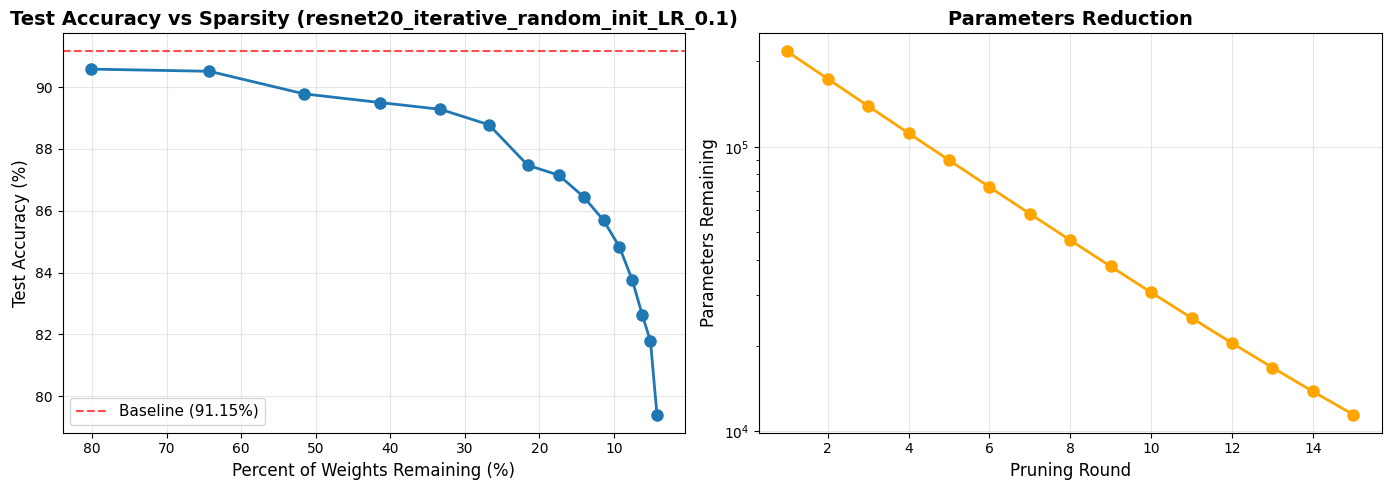

Pruning figure saved to: ../../results/resnet20_iterative_random_init_LR_0.1_20260112_025542/figures/Random_init_pruning_results_resnet20_iterative_random_init_LR_0.1_20260112_025542.png


In [14]:
# --- Visualize ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy vs Sparsity
ax1.plot(remaining_params_pct, test_accuracies, 'o-', linewidth=2, markersize=8)

# Robust baseline line handling (CPU/GPU compatible)
baseline_acc_val = 91.15
# baseline_acc_val = test_accuracy.item() if isinstance(test_accuracy, torch.Tensor) else test_accuracy
ax1.axhline(y=baseline_acc_val, color='r', linestyle='--', label=f'Baseline ({baseline_acc_val:.2f}%)', alpha=0.7)

ax1.set_xlabel('Percent of Weights Remaining (%)', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title(f'Test Accuracy vs Sparsity ({model_name})', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)
ax1.invert_xaxis() 

# Plot 2: Params Reduction
ax2.plot(rounds, remaining_params, 'o-', linewidth=2, markersize=8, color='orange')
ax2.set_xlabel('Pruning Round', fontsize=12)
ax2.set_ylabel('Parameters Remaining', fontsize=12)
ax2.set_title('Parameters Reduction', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log') # Log scale is great for pruning

plt.tight_layout()

# Save Pruning Figure
random_init_pruning_fig_path = os.path.join(fig_dir, f"Random_init_pruning_results_{run_id}.png")
plt.savefig(random_init_pruning_fig_path, dpi=150)
plt.show()

print(f"Pruning figure saved to: {random_init_pruning_fig_path}")

In [15]:
# Identify winning tickets
baseline_accuracy = 91.15
# baseline_accuracy = test_accuracy
winning_tickets_random_init = []

for r in random_init_results:
    # Winning ticket criteria: accuracy >= 98% of baseline
    if r['test_accuracy'] >= baseline_accuracy * 0.98:
        winning_tickets_random_init.append(r)

print(f"\n{'='*70}")
print(f"Found {len(winning_tickets_random_init)} Winning Tickets!")
print(f"{'='*70}")
print(f"Baseline Accuracy: {baseline_accuracy:.2f}%")
print(f"\nWinning Tickets (accuracy >= {baseline_accuracy * 0.98:.2f}%):")
print(f"{'Round':<8} {'Sparsity %':<12} {'Params':<15} {'Accuracy %':<12}")
print("-"*70)

for ticket in winning_tickets_random_init:
    sparsity = 100 - ticket['remaining_params_pct']
    print(f"{ticket['round']:<8} {sparsity:<12.1f} "
          f"{ticket['remaining_params']:<15,} {ticket['test_accuracy']:<12.2f}")

if winning_tickets_random_init:
    best_ticket = min(winning_tickets_random_init, key=lambda x: x['remaining_params'])
    print(f"\nBest Winning Ticket:")
    print(f"  Round: {best_ticket['round']}")
    print(f"  Sparsity: {100 - best_ticket['remaining_params_pct']:.1f}%")
    print(f"  Parameters: {best_ticket['remaining_params']:,}")
    print(f"  Accuracy: {best_ticket['test_accuracy']:.2f}%")


Found 4 Winning Tickets!
Baseline Accuracy: 91.15%

Winning Tickets (accuracy >= 89.33%):
Round    Sparsity %   Params          Accuracy %  
----------------------------------------------------------------------
1        19.8         216,183.0       90.58       
2        35.7         173,351.0       90.51       
3        48.4         139,086.0       89.78       
4        58.6         111,674.0       89.50       

Best Winning Ticket:
  Round: 4
  Sparsity: 58.6%
  Parameters: 111,674.0
  Accuracy: 89.50%


正在加载数据...


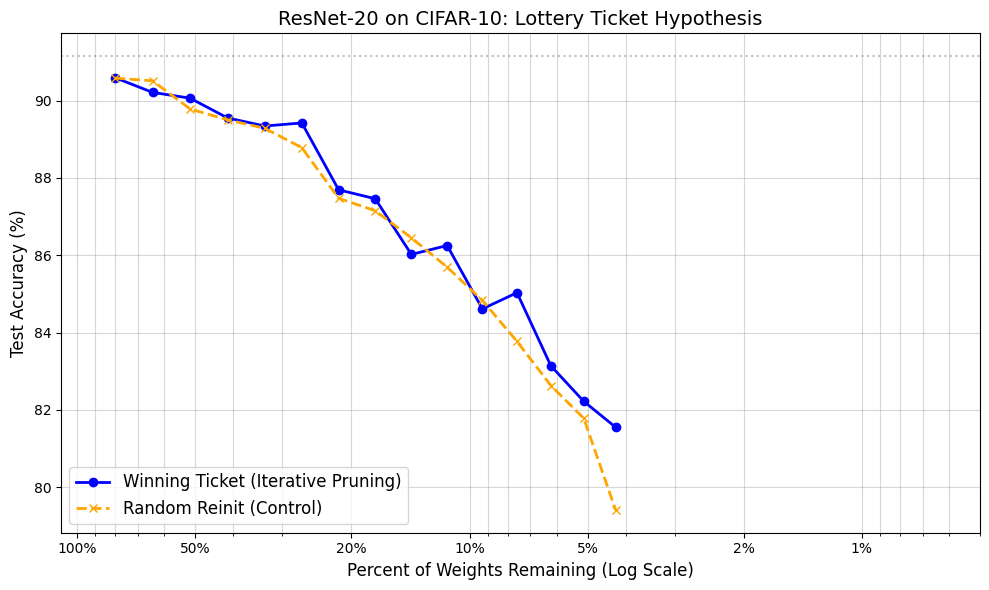

图表已保存至: ../../results/resnet20_iterative_random_init_LR_0.1_20260112_025542/figures/iterative_random_init_comparison_resnet20_iterative_random_init_LR_0.1_20260112_025542.png


In [27]:
import torch
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. 定义文件路径
# ==========================================
# 这是一个相对路径，确保你的 Notebook 和 results 文件夹的相对位置是正确的
# base_dir = "../../results/resnet20_iterative_random_init_LR_0.1_20260112_025542/checkpoints"
iterative_file = "iterative_pruning_results_resnet20_iterative_random_init_LR_0.1_20260112_025542.pth"
random_init_file = "random_init_results__resnet20_iterative_random_init_LR_0.1_20260112_025542.pth"

iterative_path = os.path.join(ckpt_dir, iterative_file)
random_init_path = os.path.join(ckpt_dir, random_init_file)

# iterative_path
# random_reinit_results_path

# ==========================================
# 2. 加载数据
# ==========================================
if not os.path.exists(iterative_path) or not os.path.exists(random_init_path):
    print("❌ 错误：找不到文件，请检查路径是否正确！")
else:
    print("正在加载数据...")
    data_iter = torch.load(iterative_path, map_location='cpu') # 加载到 CPU 方便绘图
    data_rand = torch.load(random_init_path, map_location='cpu')

    # data_iter = torch.load(iterative_results_path, map_location='cpu') # 加载到 CPU 方便绘图
    # data_rand = torch.load(random_reinit_results_path, map_location='cpu')
    
    # 提取结果列表
    res_iter = data_iter['results']
    res_rand = data_rand['results']

    # res_iter = results
    # res_rand = random_init_results
    
    # ==========================================
    # 3. 提取绘图数据 (X轴: 稀疏度, Y轴: 准确率)
    # ==========================================
    # Iterative Pruning (Winning Ticket)
    # 我们通常把 Base Model (100% 权重) 作为第一个点
    # 注意：你的 results 列表里可能第一项就是 Pruned 后的，
    # 如果第一轮训练前没有存 100% 的结果，我们主要看后面的趋势
    
    x_iter = [item['remaining_params_pct'] for item in res_iter]
    y_iter = [item['test_accuracy'] for item in res_iter]
    
    
    # Random Init (Control)
    x_rand = [item['remaining_params_pct'] for item in res_rand]
    y_rand = [item['test_accuracy'] for item in res_rand]
    
    # ==========================================
    # 4. 绘制对比图 (复现论文风格)
    # ==========================================
    plt.figure(figsize=(10, 6))
    
    # 绘制曲线
    plt.plot(x_iter, y_iter, marker='o', label='Winning Ticket (Iterative Pruning)', color='blue', linewidth=2)
    plt.plot(x_rand, y_rand, marker='x', label='Random Reinit (Control)', color='orange', linestyle='--', linewidth=2)
    
    # 设置 X 轴为对数坐标 (论文通常这样做，因为后期稀疏度变化很小但影响很大)
    plt.xscale('log')
    
    # 反转 X 轴 (让 100% 在左边，0.1% 在右边，符合阅读习惯)
    plt.xlim(110, 0.5)  # 范围从 110% 到 0.5% (根据你的数据调整)
    
    # 设置刻度标签，让它显示为正常的百分比数字
    plt.xticks([100, 50, 20, 10, 5, 2, 1], ['100%', '50%', '20%', '10%', '5%', '2%', '1%'])
    
    # 添加标签和标题
    plt.title('ResNet-20 on CIFAR-10: Lottery Ticket Hypothesis', fontsize=14)
    plt.xlabel('Percent of Weights Remaining (Log Scale)', fontsize=12)
    plt.ylabel('Test Accuracy (%)', fontsize=12)
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend(fontsize=12)
    
    # 添加辅助线 (可选，标出 Baseline 精度)
    # baseline_acc = y_iter[0] 
    baseline_acc = 91.15 
    plt.axhline(y=baseline_acc, color='gray', linestyle=':', alpha=0.5, label='Baseline Accuracy')
    
    plt.tight_layout()
    
    # 保存图片
    # random_init_pruning_fig_path = os.path.join(fig_dir, f"Random_init_pruning_results_{run_id}.png")
    save_comparison_fig_path = os.path.join(fig_dir, f"iterative_random_init_comparison_{run_id}.png") # 假设有个 figures 文件夹
    # os.makedirs(save_fig_path, exist_ok=True)
    plt.savefig(save_comparison_fig_path, dpi=150)
    
    plt.show()
    
    print(f"图表已保存至: {save_comparison_fig_path}")

正在加载数据...


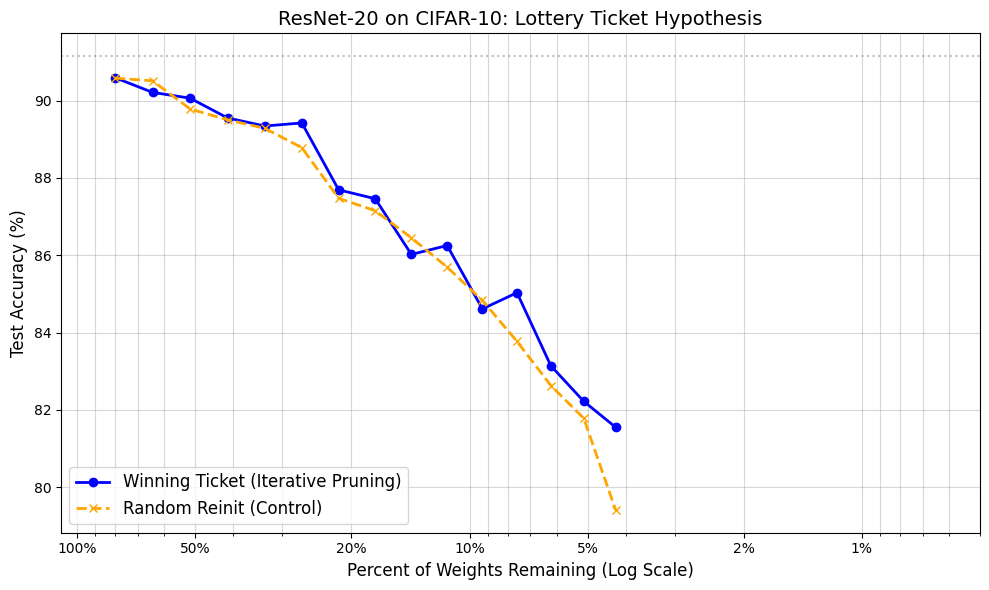

图表已保存至: ../../results/resnet20_iterative_random_init_LR_0.1_20260112_025542/figures/iterative_random_init_comparison_resnet20_iterative_random_init_LR_0.1_20260112_025542.png


In [28]:
import torch
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. 定义文件路径
# ==========================================
# 这是一个相对路径，确保你的 Notebook 和 results 文件夹的相对位置是正确的
# base_dir = "../../results/resnet20_iterative_random_init_LR_0.1_20260112_025542/checkpoints"
# iterative_file = "iterative_pruning_results_resnet20_iterative_random_init_LR_0.1_20260112_025542.pth"
# random_init_file = "random_init_results__resnet20_iterative_random_init_LR_0.1_20260112_025542.pth"

# iterative_path = os.path.join(ckpt_dir, iterative_file)
# random_init_path = os.path.join(ckpt_dir, random_init_file)

# iterative_path
# random_reinit_results_path

# ==========================================
# 2. 加载数据
# ==========================================
# if not os.path.exists(iterative_path) or not os.path.exists(random_init_path):
#     print("❌ 错误：找不到文件，请检查路径是否正确！")
# else:


print("正在加载数据...")
# data_iter = torch.load(iterative_path, map_location='cpu') # 加载到 CPU 方便绘图
# data_rand = torch.load(random_init_path, map_location='cpu')

# data_iter = torch.load(iterative_results_path, map_location='cpu') # 加载到 CPU 方便绘图
# data_rand = torch.load(random_reinit_results_path, map_location='cpu')

# 提取结果列表
# res_iter = data_iter['results']
# res_rand = data_rand['results']

res_iter = results
res_rand = random_init_results

# ==========================================
# 3. 提取绘图数据 (X轴: 稀疏度, Y轴: 准确率)
# ==========================================
# Iterative Pruning (Winning Ticket)
# 我们通常把 Base Model (100% 权重) 作为第一个点
# 注意：你的 results 列表里可能第一项就是 Pruned 后的，
# 如果第一轮训练前没有存 100% 的结果，我们主要看后面的趋势

x_iter = [item['remaining_params_pct'] for item in res_iter]
y_iter = [item['test_accuracy'] for item in res_iter]

# Random Init (Control)
x_rand = [item['remaining_params_pct'] for item in res_rand]
y_rand = [item['test_accuracy'] for item in res_rand]

# ==========================================
# 4. 绘制对比图 (复现论文风格)
# ==========================================
plt.figure(figsize=(10, 6))

# 绘制曲线
plt.plot(x_iter, y_iter, marker='o', label='Winning Ticket (Iterative Pruning)', color='blue', linewidth=2)
plt.plot(x_rand, y_rand, marker='x', label='Random Reinit (Control)', color='orange', linestyle='--', linewidth=2)

# 设置 X 轴为对数坐标 (论文通常这样做，因为后期稀疏度变化很小但影响很大)
plt.xscale('log')

# 反转 X 轴 (让 100% 在左边，0.1% 在右边，符合阅读习惯)
plt.xlim(110, 0.5)  # 范围从 110% 到 0.5% (根据你的数据调整)

# 设置刻度标签，让它显示为正常的百分比数字
plt.xticks([100, 50, 20, 10, 5, 2, 1], ['100%', '50%', '20%', '10%', '5%', '2%', '1%'])

# 添加标签和标题
plt.title('ResNet-20 on CIFAR-10: Lottery Ticket Hypothesis', fontsize=14)
plt.xlabel('Percent of Weights Remaining (Log Scale)', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(fontsize=12)

# 添加辅助线 (可选，标出 Baseline 精度)
# baseline_acc = y_iter[0] 
baseline_acc = 91.15 
plt.axhline(y=baseline_acc, color='gray', linestyle=':', alpha=0.5, label='Baseline Accuracy')

plt.tight_layout()

# 保存图片
# random_init_pruning_fig_path = os.path.join(fig_dir, f"Random_init_pruning_results_{run_id}.png")
save_comparison_fig_path = os.path.join(fig_dir, f"iterative_random_init_comparison_{run_id}.png") # 假设有个 figures 文件夹
# os.makedirs(save_fig_path, exist_ok=True)
plt.savefig(save_comparison_fig_path, dpi=150)

plt.show()

print(f"图表已保存至: {save_comparison_fig_path}")

## 6. Analyze Results

### 6.1 Iterative Pruning

Visualize and analyze the pruning results.

## 7. Identify Winning Tickets

Find which pruned networks are "winning tickets" (match or exceed baseline accuracy).

## 8. Save Results

## 9. Next Steps

### Experiment Ideas:

1. **Compare pruning strategies**
   - Try different `prune_rate_conv` and `prune_rate_fc`
   - Compare `layerwise` vs `global` pruning

2. **Random reinitialization baseline**
   - Use `random_reinit_pruning()` to show winning tickets need original initialization

3. **One-shot pruning**
   - Compare `one_shot_pruning()` vs iterative pruning

4. **Visualize weight distributions**
   - Plot weight magnitude histograms before/after pruning

5. **Learning rate experiments**
   - Test different learning rates (paper shows this matters!)

## Notes and Observations

**TODO: Add your observations here**

- What worked well?
- What surprised you?
- Any implementation challenges?
- Ideas for the final report?